In [14]:
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns

In [15]:
class DynamicNdLinear(nn.Module):
    def __init__(self, in_dims, out_dims):
        super().__init__()
        assert len(in_dims) == len(out_dims), "Mismatch in dimensions"
        self.n = len(in_dims)
        self.in_dims, self.out_dims = list(in_dims), list(out_dims)

        self.W = nn.ParameterList([
            nn.Parameter(torch.randn(D, H) * 0.02)
            for D, H in zip(in_dims, out_dims)
        ])
        self.b = nn.ParameterList([
            nn.Parameter(torch.zeros(H))
            for H in out_dims
        ])

        flat_dim = 1
        for d in in_dims:
            flat_dim *= d
        self.gate = nn.Sequential(
            nn.Linear(flat_dim, 128),
            nn.ReLU(inplace=True),
            nn.Linear(128, self.n),
            nn.Softmax(dim=1)
        )

    def forward(self, X):
        B = X.size(0)
        flat = X.reshape(B, -1)
        gates = self.gate(flat)

        out = X
        current = list(self.in_dims)

        for axis in range(self.n):
            prev = out
            perm = list(range(1, self.n + 1))
            perm[axis], perm[-1] = perm[-1], perm[axis]
            out_perm = out.permute(0, *perm)

            rest = int(torch.prod(torch.tensor(out_perm.shape[1:-1])))
            mat = out_perm.reshape(B * rest, current[axis])
            proj = mat @ self.W[axis] + self.b[axis]

            shape_after = [B] + [out.shape[p] for p in perm]
            shape_after[-1] = self.out_dims[axis]
            out_new = proj.reshape(*shape_after)

            inv = [0] + [perm.index(i)+1 for i in range(1, self.n+1)]
            out_new = out_new.permute(*inv)

            if current[axis] == self.out_dims[axis]:
                w = gates[:, axis].view(B, *([1] * self.n))
                out = w * out_new + (1 - w) * prev
            else:
                out = out_new

            current[axis] = self.out_dims[axis]

        return out, gates


In [16]:
class CIFARDynamicClassifier(nn.Module):
    def __init__(self):
        super().__init__()
        self.backbone = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1), nn.ReLU(),
            nn.Conv2d(32, 32, 3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2)
        )
        self.dynamic_nd = DynamicNdLinear((8, 8, 64), (8, 8, 16))
        self.classifier = nn.Linear(8 * 8 * 16, 10)

    def forward(self, x):
        B = x.size(0)
        x = self.backbone(x)
        x = x.permute(0, 2, 3, 1)
        x, gates = self.dynamic_nd(x)
        x = x.reshape(B, -1)
        return self.classifier(x), gates


In [17]:
def train_epoch(model, loader, optimizer, loss_fn, device):
    model.train()
    total_loss = 0
    total_correct = 0
    total = 0

    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        logits, _ = model(xb)
        loss = loss_fn(logits, yb)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * xb.size(0)
        total_correct += (logits.argmax(1) == yb).sum().item()
        total += xb.size(0)

    return total_loss / total, total_correct / total

In [18]:
def plot_training_curves(loss_history, acc_history):
    epochs = range(1, len(loss_history) + 1)
    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.plot(epochs, loss_history, marker='o')
    plt.title("Training Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")

    plt.subplot(1, 2, 2)
    plt.plot(epochs, acc_history, marker='o', color='green')
    plt.title("Training Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")

    plt.tight_layout()
    plt.show()

In [19]:
def evaluate_model(model, dataloader, device, model_name="Model"):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for xb, yb in dataloader:
            xb, yb = xb.to(device), yb.to(device)
            logits, _ = model(xb)
            preds = logits.argmax(1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(yb.cpu().numpy())

    acc = accuracy_score(all_labels, all_preds)
    print(f"\n{model_name} — Accuracy: {acc:.4f}\n")
    print("Classification Report:")
    print(classification_report(all_labels, all_preds, digits=4))

    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=range(10), yticklabels=range(10))
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title(f"Confusion Matrix: {model_name}")
    plt.show()



In [20]:
def run_dynamic_ndlinear():
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    transform = transforms.Compose([transforms.ToTensor()])
    train_set = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
    test_set = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)

    train_loader = DataLoader(train_set, batch_size=128, shuffle=True)
    test_loader = DataLoader(test_set, batch_size=128, shuffle=False)

    model = CIFARDynamicClassifier().to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    loss_fn = nn.CrossEntropyLoss()

    loss_history = []
    acc_history = []

    for epoch in range(1, 11):
        loss, acc = train_epoch(model, train_loader, optimizer, loss_fn, device)
        loss_history.append(loss)
        acc_history.append(acc)
        print(f"Epoch {epoch:2d} — Loss: {loss:.4f}, Acc: {acc:.4f}")

    plot_training_curves(loss_history, acc_history)
    evaluate_model(model, test_loader, device, model_name="CIFAR-10 DynamicNdLinear")



Epoch  1 — Loss: 1.7333, Acc: 0.3762
Epoch  2 — Loss: 1.3459, Acc: 0.5223
Epoch  3 — Loss: 1.2318, Acc: 0.5666
Epoch  4 — Loss: 1.1421, Acc: 0.5971
Epoch  5 — Loss: 1.0440, Acc: 0.6351
Epoch  6 — Loss: 0.9587, Acc: 0.6652
Epoch  7 — Loss: 0.9051, Acc: 0.6868
Epoch  8 — Loss: 0.8601, Acc: 0.7016
Epoch  9 — Loss: 0.8258, Acc: 0.7141
Epoch 10 — Loss: 0.7910, Acc: 0.7268


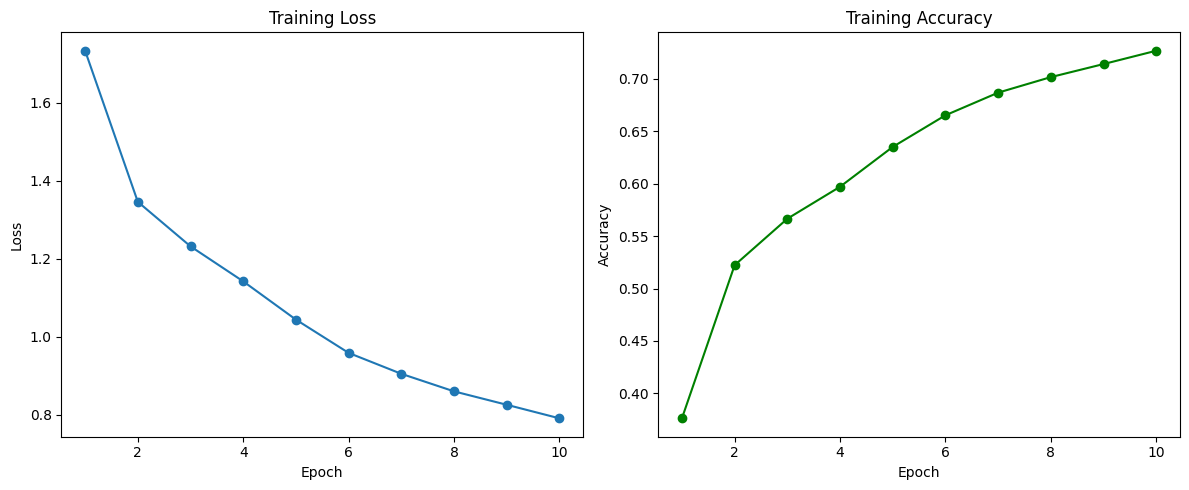


CIFAR-10 DynamicNdLinear — Accuracy: 0.6937

Classification Report:
              precision    recall  f1-score   support

           0     0.6917    0.7450    0.7174      1000
           1     0.8963    0.7610    0.8231      1000
           2     0.5108    0.6640    0.5774      1000
           3     0.4804    0.5880    0.5288      1000
           4     0.7667    0.4370    0.5567      1000
           5     0.6220    0.5990    0.6103      1000
           6     0.8397    0.7230    0.7770      1000
           7     0.7319    0.7780    0.7542      1000
           8     0.7673    0.8540    0.8083      1000
           9     0.8041    0.7880    0.7960      1000

    accuracy                         0.6937     10000
   macro avg     0.7111    0.6937    0.6949     10000
weighted avg     0.7111    0.6937    0.6949     10000



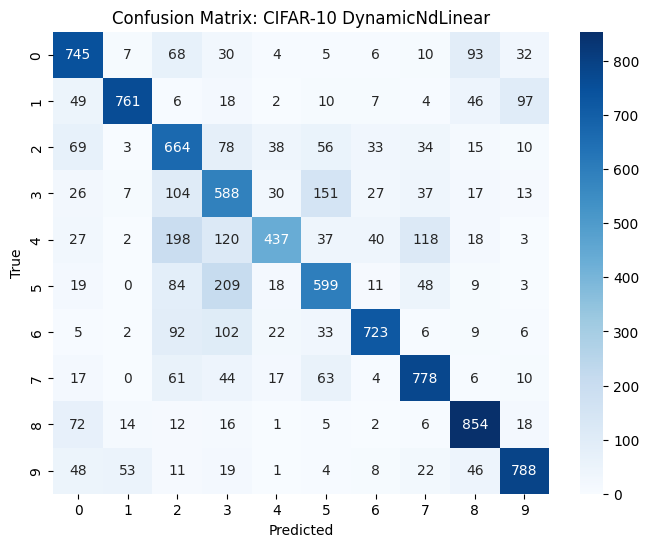

In [21]:
run_dynamic_ndlinear()